# Brazilian E-Commerce Dataset - EDA and Data Preparation

## Data Source Used

This is a Brazilian ecommerce public dataset of orders made at Olist Store. The dataset has information of 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil. Its features allows viewing an order from multiple dimensions: from order status, price, payment and freight performance to customer location, product attributes and finally reviews written by customers. There is also a geolocation dataset that relates Brazilian zip codes to lat/lng coordinates.

This dataset was generously provided by Olist, the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners. 

After a customer purchases the product from Olist Store a seller gets notified to fulfill that order. Once the customer receives the product, or the estimated delivery date is due, the customer gets a satisfaction survey by email where he can give a note for the purchase experience and write down some comments.

## Exploratory Data Analysis and Pre-Processing

### Database Schema

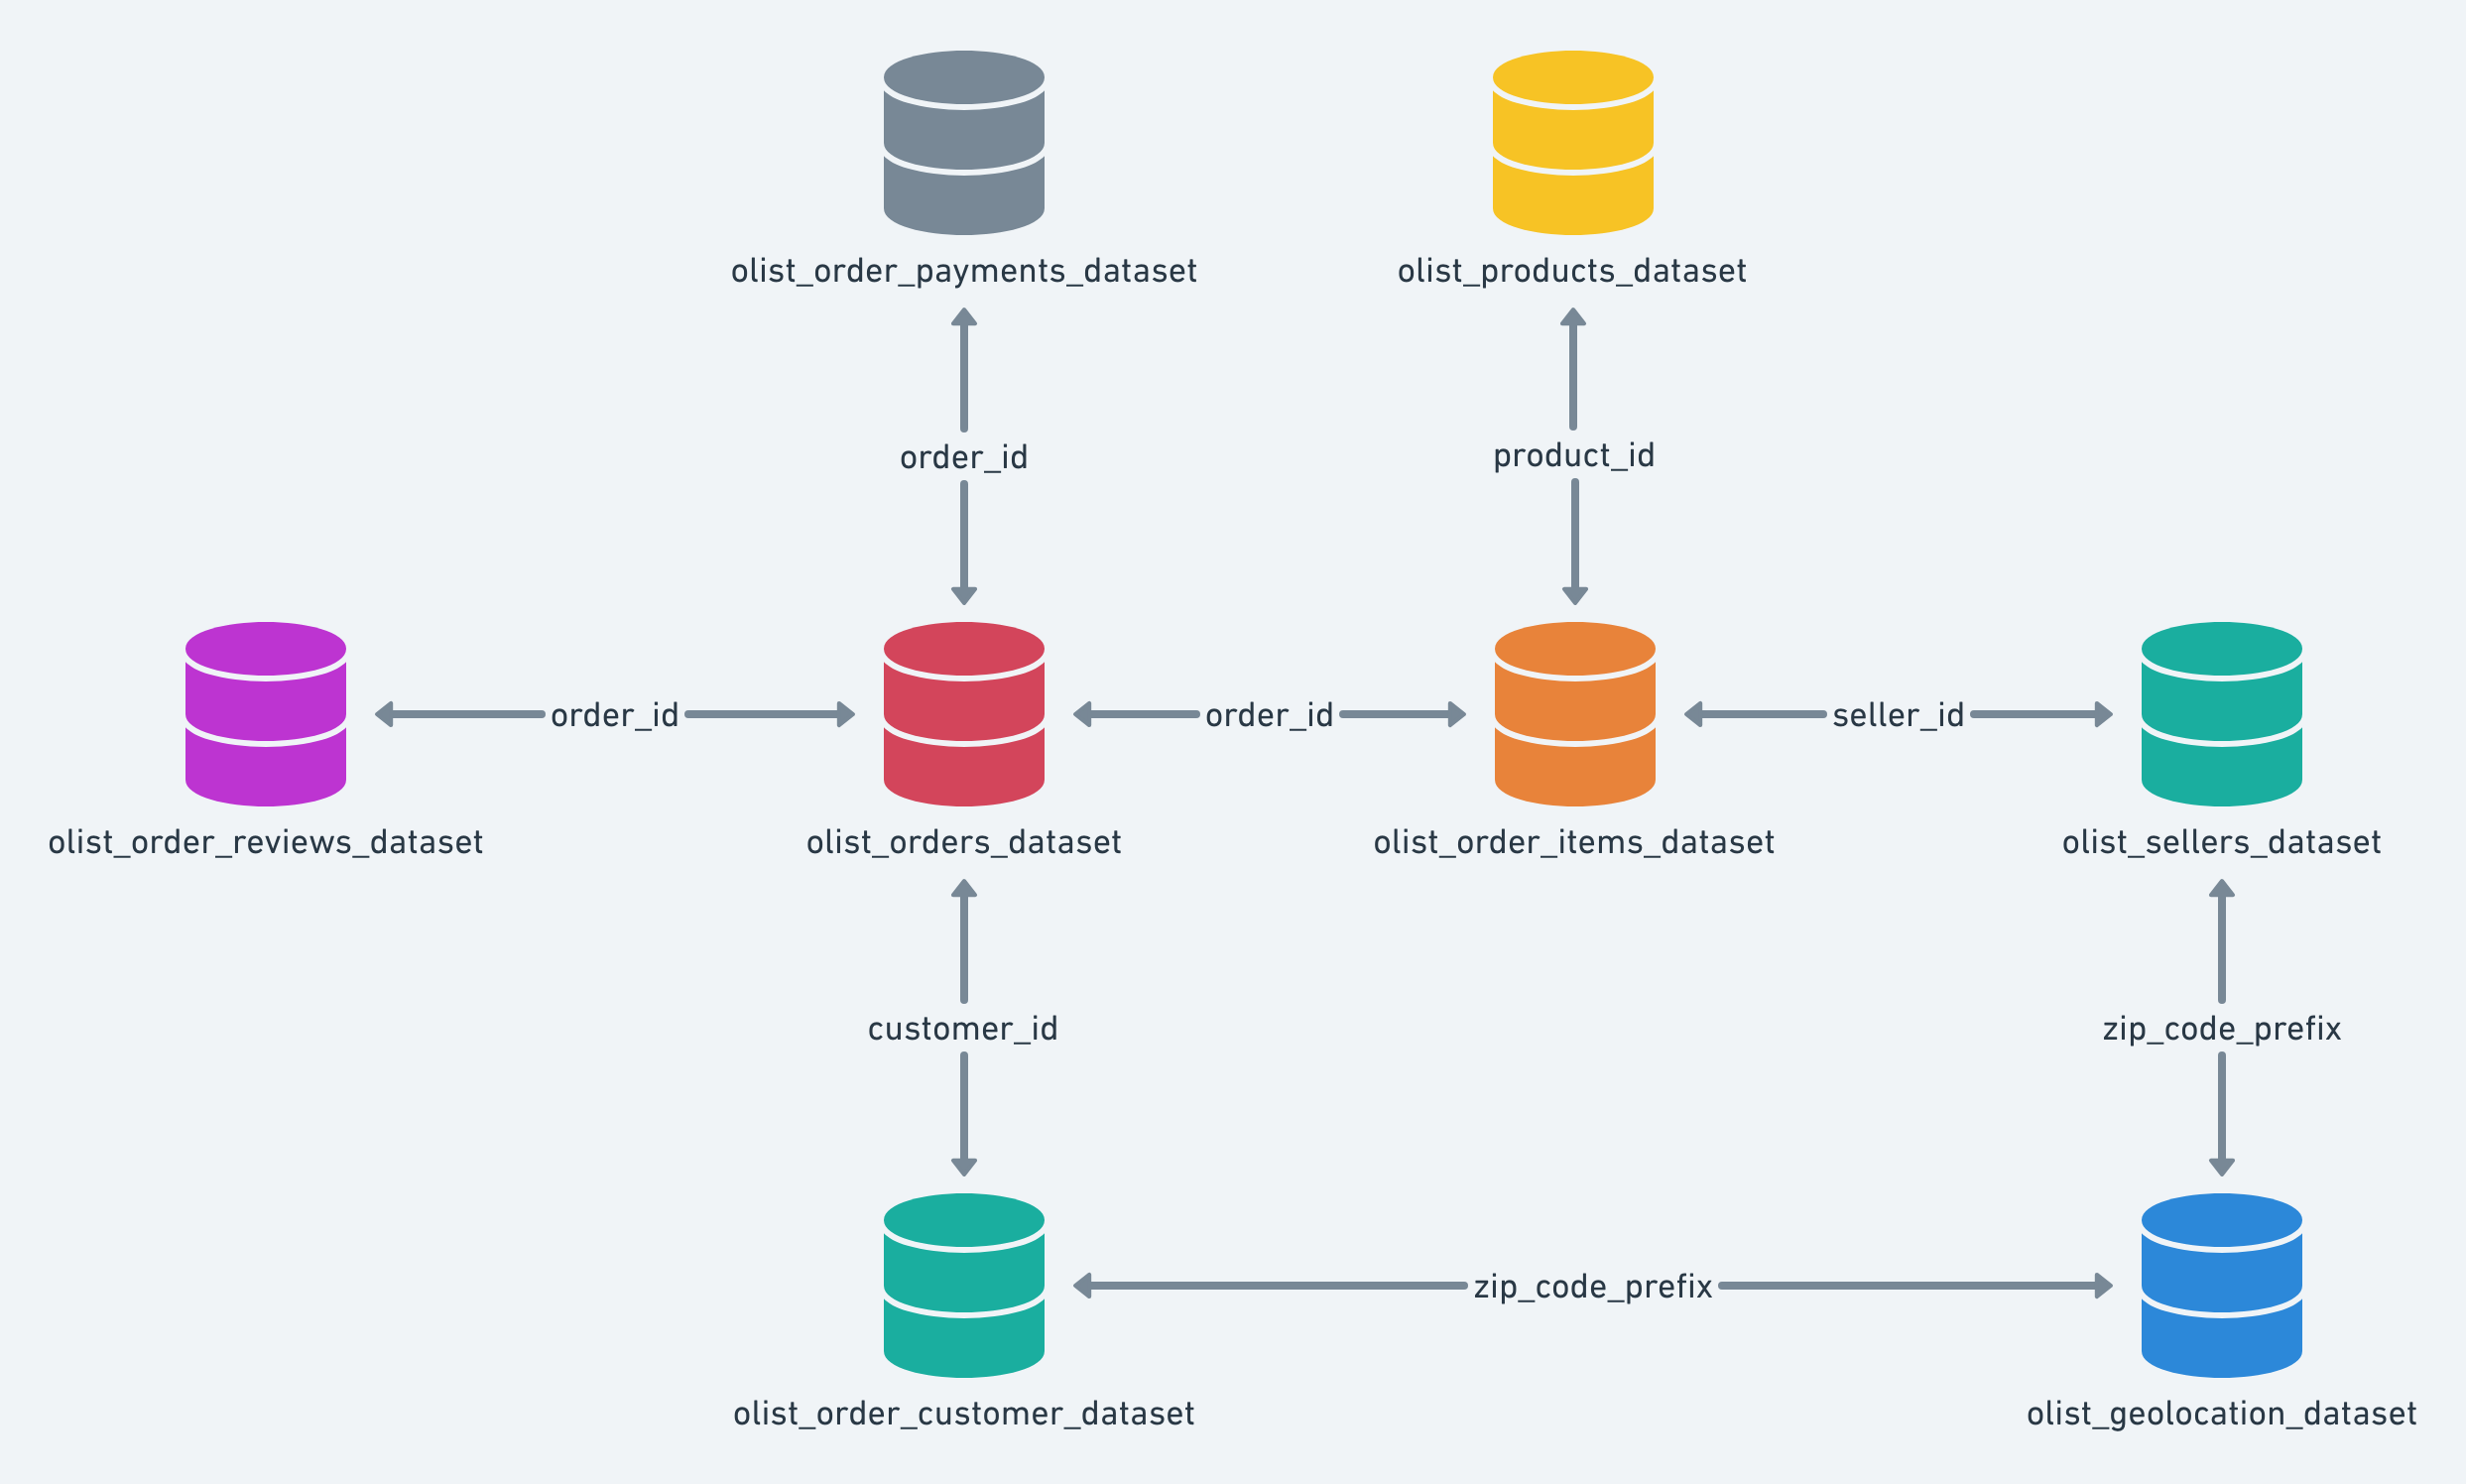

As we can see, the database comprises of several tables. In the following cells, we will analyze each table individually and perform preprocessing to prevent extra space consumption.

### Setting Up

To start, we download the following libraries:

- NumPy: to work with the data
- Pandas: to manipulate the data
- MatPlotLib: for data visualization
- Seaborn: for data visualization

In [1]:
# importing the libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

Next, we read the datasets and store it into a dataframe using the read_csv() function from the Pandas library.

In [2]:
# reading the datasets
customer = pd.read_csv('../input/brazilian-ecommerce/olist_customers_dataset.csv')
geo = pd.read_csv('../input/brazilian-ecommerce/olist_geolocation_dataset.csv')
item = pd.read_csv('../input/brazilian-ecommerce/olist_order_items_dataset.csv')
payment = pd.read_csv('../input/brazilian-ecommerce/olist_order_payments_dataset.csv')
review = pd.read_csv('../input/brazilian-ecommerce/olist_order_reviews_dataset.csv')
order = pd.read_csv('../input/brazilian-ecommerce/olist_orders_dataset.csv')
product = pd.read_csv('../input/brazilian-ecommerce/olist_products_dataset.csv')
seller = pd.read_csv('../input/brazilian-ecommerce/olist_sellers_dataset.csv')
prodinfo = pd.read_csv('../input/brazilian-ecommerce/product_category_name_translation.csv')

#### Customer Table (olist_customers_dataset)

The Customer Table comprises of the following columns:

- customer_id: key to the orders dataset. Each order has a unique customer_id.
- customer_unique_id: unique identifier of a customer.

In this system each order is assigned to a unique customerid. This means that the same customer will get different ids for different orders. The purpose of having a customer_unique_id on the dataset is to allow you to identify customers that made repurchases at the store. Otherwise you would find that each order had a different customer associated with.

- customer_zip_code_prefix: first five digits of customer zip code.
- customer_city: customer city name.
- customer_state: customer state.

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [3]:
# viewing the first 5 rows of the dataset
customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [4]:
# checking for missing values
customer.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

As we can see, there are no missing values in the table.

Let's now find some insights of the data.

In [5]:
# finding some insights
print('Cities with Sales: ', customer.customer_city.nunique())
print('States with Sales: ', customer.customer_state.nunique())
print(str.format('Average Number of Cities per State: {:.0f}', customer.groupby(by='customer_state').customer_city.value_counts().mean()))

Cities with Sales:  4119
States with Sales:  27
Average Number of Cities per State: 23


As we can see there are:
- 4119 cities in which sales occur
- 27 states in which sales occur
- on average 23 cities per state


Next, we visualize the number of customers per state. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Customers')

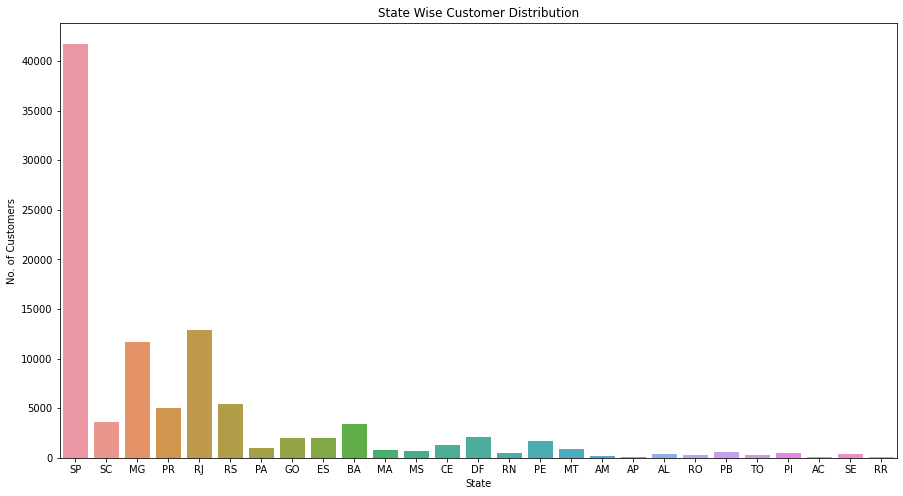

In [6]:
# plotting state wise customer distribution
plt.figure(figsize=(15,8))
sns.countplot(x='customer_state', data=customer)
plt.title('State Wise Customer Distribution')
plt.xlabel('State')
plt.ylabel('No. of Customers')

As we can see, the most number of customer come from state code 'SP', followed by 'RJ' and 'MG', which are all situated in the SouthEast region of Brazil.

#### Geo Table (olist_geolocation_dataset)

The Geo Table comprises of the following table:

- geolocation_zip_code_prefix: first 5 digits of zip code.
- geolocation_lat: latitude
- geolocation_lng: longitude
- geolocation_city: city
- geolocation_state state

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [7]:
# viewing the first 5 rows of the dataset
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [8]:
# checking for missing values
geo.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

As we can see, there are no missing values.

Let's now visualize the data points on a map. To do this, we use functions from the GeoPandas and Shapely libraries.

/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


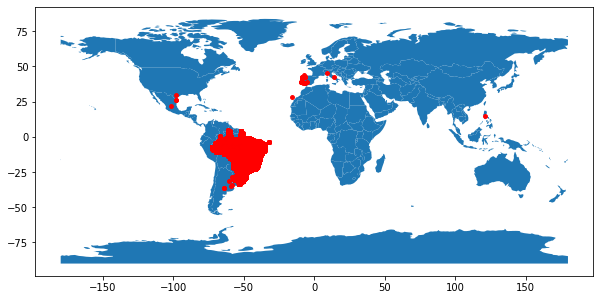

In [9]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame

geometry = [Point(xy) for xy in zip(geo['geolocation_lng'], geo['geolocation_lat'])]
gdf = GeoDataFrame(geo, geometry=geometry)   

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='red', markersize=15);

As we can see, most of the orders come from Brazilian cities, however, there are a few orders which come from North America, Europe, and Asia.

#### Item Table (olist_order_items_dataset)

The Item Table comprises of the following columns:

- order_id: order unique identifier.
- order_item_id: sequential number identifying number of items included in the same order.
- product_id: product unique identifier.
- seller_id: seller unique identifier.
- shipping_limit_date: shows the seller shipping limit date for handling the order over to the logistic partner.
- price: item price.
- freight_value: item freight value item (if an order has more than one item the freight value is splitted between items).

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [10]:
# viewing the first 5 rows of the dataset
item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [11]:
# checking for missing values
item.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

As we can see, there are no missing values in the dataset.

Next, we plot the distribution of price. To do this, we use the histplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value. 

Text(0.5, 0, 'Price')

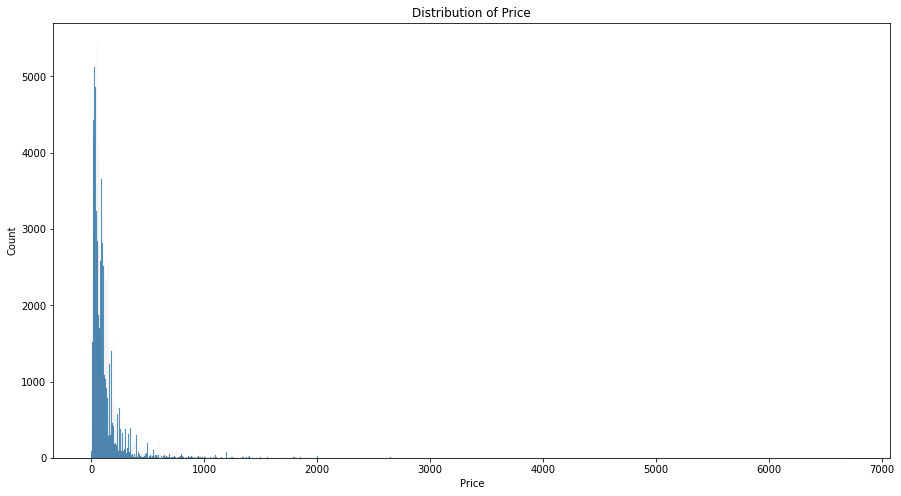

In [12]:
# plotting the distribution of price
plt.figure(figsize=(15,8))
sns.histplot(x='price', data=item)
plt.title('Distribution of Price')
plt.xlabel('Price')

As we can see, most orders are under 1000 Brazilian Reals.


After that, we plot the distribution of freight value. To do this, we use the histplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0.5, 0, 'Freight Value')

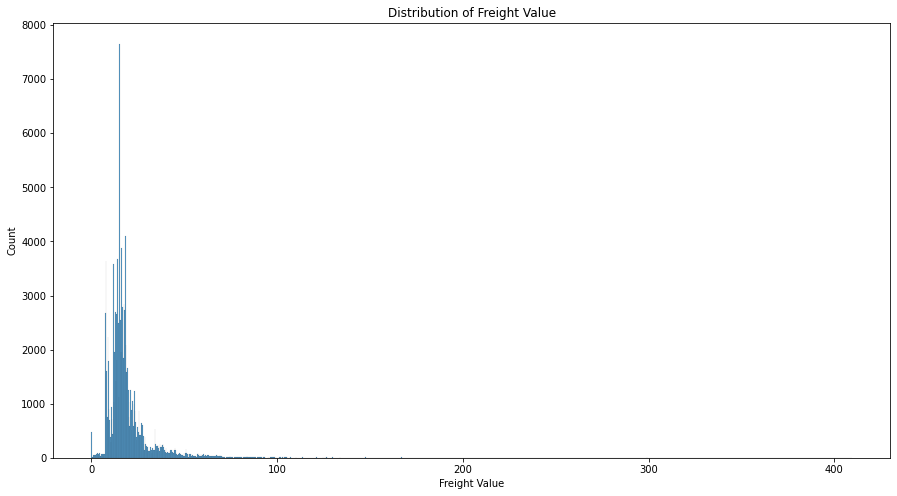

In [13]:
# plotting the distribution of freight value
plt.figure(figsize=(15,8))
sns.histplot(x='freight_value', data=item)
plt.title('Distribution of Freight Value')
plt.xlabel('Freight Value')

As we can see, most values are under 100 kg. 

#### Payment Table (olist_order_payments_dataset)

The Payment Table comprises of the following columns:

- order_id: unique identifier of an order.
- payment_sequential: a customer may pay an order with more than one payment method. If he does so, a sequence will be created.
- payment_type: method of payment chosen by the customer.
- payment_installments: number of installments chosen by the customer.
- payment_value: transaction value.

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [14]:
# viewing the first 5 rows of the dataset
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [15]:
# checking for missing values
payment.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

As we can see, there are no missing values.

For more insights, we analyze the payment types. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Customers')

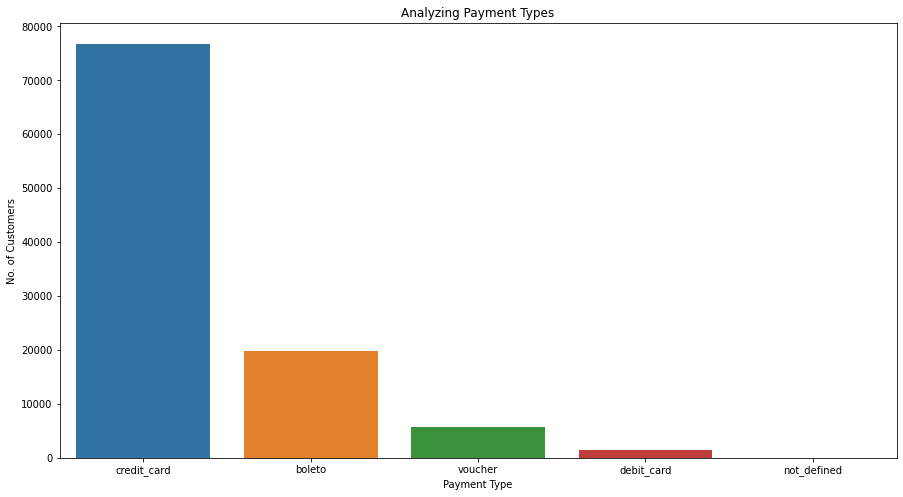

In [16]:
# analyzing the payment methods chosen by different customers
plt.figure(figsize=(15,8))
sns.countplot(x='payment_type', data=payment)
plt.title('Analyzing Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('No. of Customers')

As we can see, most customers prefer credit card, followed by boleto, voucher and then debit card. We can also see the presence of a 'not_defined' value which is analogous to missing values. We remove such values using the loc() function from the Pandas library. This means that most customers pre-pay for their orders, indicating trust in the site.

In [17]:
# removing not_defined payment method
payment = payment.loc[payment['payment_type']!='not_defined', :]

Next, we plot the distribution of number of installments. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Customers')

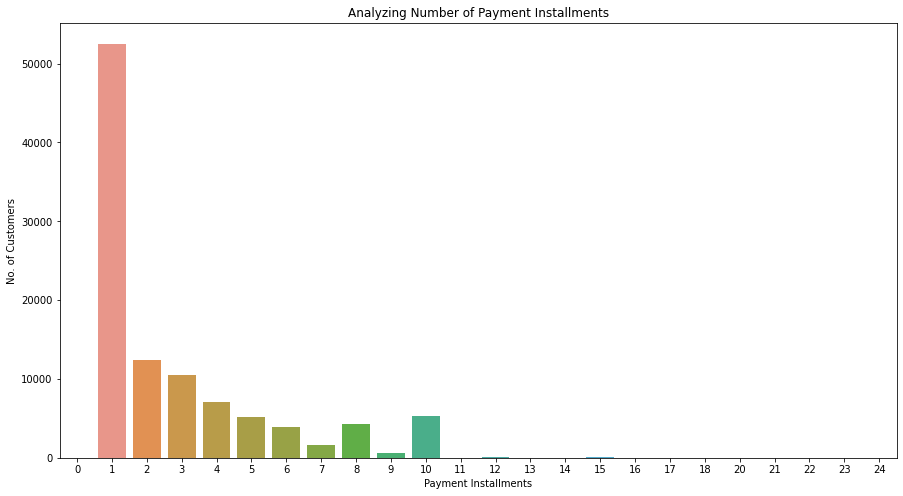

In [18]:
# plotting the distribution of number of installments
plt.figure(figsize=(15,8))
sns.countplot(x='payment_installments', data=payment)
plt.title('Analyzing Number of Payment Installments')
plt.xlabel('Payment Installments')
plt.ylabel('No. of Customers')

As we can see, most customers prefer payment via only one installment. However, customers also opt for more than one installment, the number is not insignificant.

Next, we plot the distribution of payment value. To do this, we use the histplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Orders')

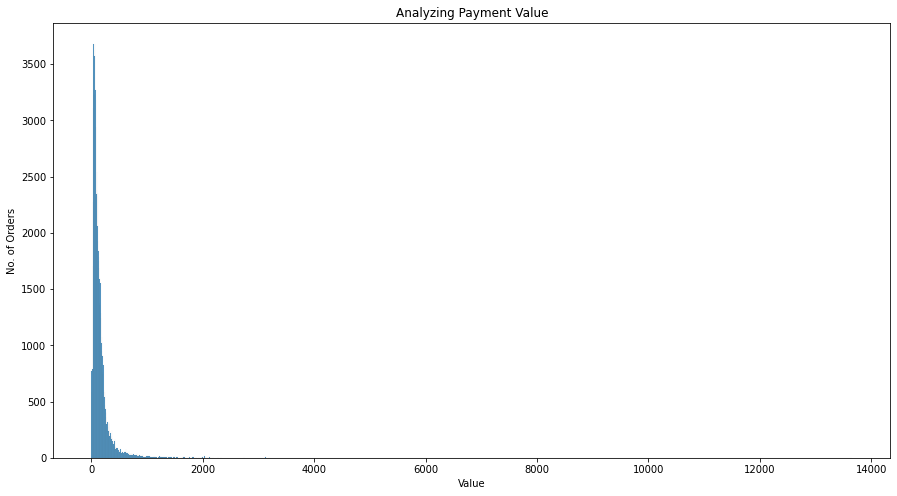

In [19]:
# plotting the distribution of payment value
plt.figure(figsize=(15,8))
sns.histplot(x='payment_value', data=payment)
plt.title('Analyzing Payment Value')
plt.xlabel('Value')
plt.ylabel('No. of Orders')

As we can see, most payments are under 1000 Brazilian Reals.

Next, we see amount paid by each payment method. To do this, we use the barplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'Amount Spent')

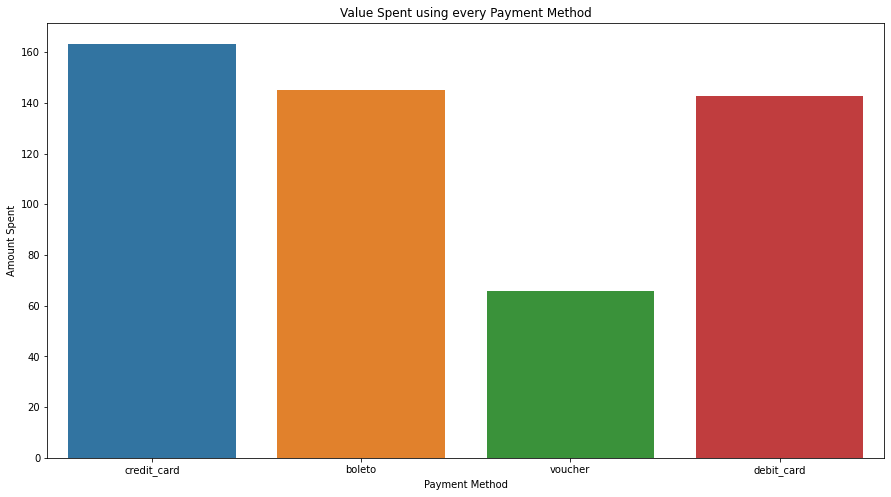

In [20]:
# analyzing amount paid by each payment method
plt.figure(figsize=(15,8))
sns.barplot(x='payment_type', y='payment_value', data=payment, ci=None)
plt.title('Value Spent using every Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Amount Spent')

As we can see, most amount is paid by credit card, followed by debit card and boleto and at the end voucher.

#### Review Table (olist_order_reviews_dataset)

The Review Table comprises of the following columns:

- review_id: unique review identifier.
- order_id: unique order identifier.
- review_score: note ranging from 1 to 5 given by the customer on a satisfaction survey.
- review_comment_title: comment title from the review left by the customer, in Portuguese.
- review_comment_message: comment message from the review left by the customer, in Portuguese.
- review_creation_date: shows the date in which the satisfaction survey was sent to the customer. 
- review_answer_timestamp: shows satisfaction survey answer timestamp.

After a customer purchases the product from Olist Store a seller gets notified to fulfill that order. Once the customer receives the product, or the estimated delivery date is due, the customer gets a satisfaction survey by email where he can give a note for the purchase experience and write down some comments.

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [21]:
# viewing the first 5 rows of the dataset
review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [22]:
# checking for missing values
review.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

As we can see, there are missing values. To decide how to deal with them, we need to know the percentage of missing values. To do this, we view the dimensions of the dataset using the shape attribute.

In [23]:
# viewing the dimensions of the dataset
review.shape

(99224, 7)

As we can see, the columns review_comment_title and review_comment_message have more than 50% missing values. Hence, we decide to drop these columns using the drop() function from the Pandas library.

In [24]:
# dropping columns with many missing values
review = review.drop(columns=['review_comment_title', 'review_comment_message'])

Next, we analyze the review scores using the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Reviews')

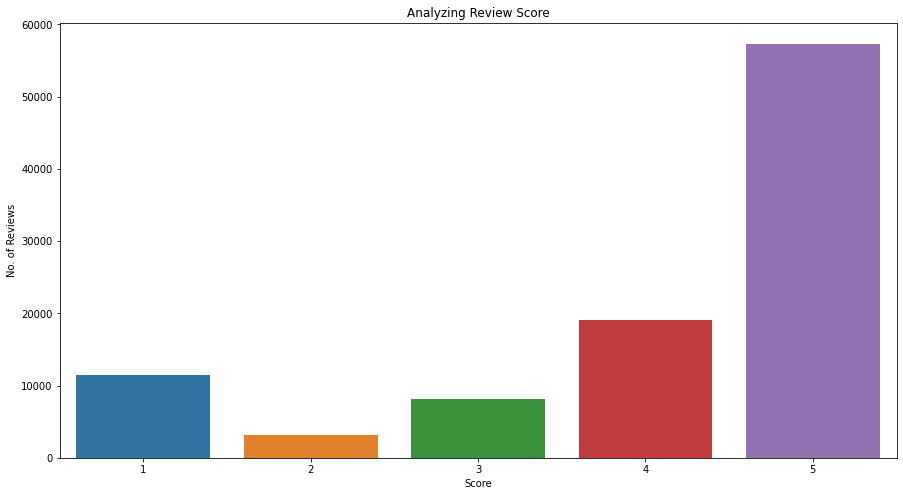

In [25]:
# analyzing the review score
plt.figure(figsize=(15,8))
sns.countplot(x='review_score', data=review)
plt.title('Analyzing Review Score')
plt.xlabel('Score')
plt.ylabel('No. of Reviews')

As we can see, most customers are satisfied with the service and have given 4 and 5 ratings accordingly. Followed by that, many customers have given a raitng of 1, which means that they are dissapointed with the service.

#### Order Table (olist_orders_dataset)

The Order Table comprises of the following columns:

- order_id: unique identifier of the order.
- customer_id: key to the customer dataset. Each order has a unique customer_id.
- order_status: reference to the order status (delivered, shipped, etc).
- order_purchase_timestamp: shows the purchase timestamp.
- order_approved_at: shows the payment approval timestamp.
- order_delivered_carrier_date: shows the order posting timestamp. When it was handled to the logistic partner.
- order_delivered_customer_date: shows the actual order delivery date to the customer.
- order_estimated_delivery date: shows the estimated delivery date that was informed to customer at the purchase moment.

To start off, we view the first few rows of the table using the head() function from the Pandas library.

In [26]:
# viewing the first 5 rows of the dataset
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [27]:
# checking for missing values
order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

As we can see, there are missing values. To decide how to deal with them, we need to know the percentage of missing values. To do this, we view the dimensions of the dataset using the shape attribute.

In [28]:
# viewing the dimensions of the dataset
order.shape

(99441, 8)

Since we have less than 20% missing values in the column, we just remove the rows which have missing values using the dropna() function from the Pandas library.

In [29]:
# dropping the missing values
order = order.dropna()

Now we analyze the status of orders. To do this, we use the value_counts() function from the Pandas library. 

In [30]:
# analyzing the order status
order.order_status.value_counts()

delivered    96455
canceled         6
Name: order_status, dtype: int64

As we can see, only 6 orders were canceled and rest all were delivered.

Next, we engineer the following features:

- diff_app_pur: the difference between the time the order was placed and the time it was approved in seconds
- diff_car_app: the difference between the time the order was approved and the time the order was delivered to the logistic partner in days
- diff_del_car: the time taken between when the order was delivered to the customer after the order was delivered to the logistic partner in days
- diff_est_act: the difference between the estimated date of arrival and the actual date of arrival in days

In [31]:
# engineering features
from datetime import datetime as dt
order['diff_app_pur'] = (pd.to_datetime(order.order_approved_at) - pd.to_datetime(order.order_purchase_timestamp)).dt.seconds
order['diff_car_app'] = (pd.to_datetime(order.order_delivered_carrier_date) - pd.to_datetime(order.order_approved_at)).dt.days
order['diff_del_car'] = (pd.to_datetime(order.order_delivered_customer_date) - pd.to_datetime(order.order_delivered_carrier_date)).dt.days
order['diff_est_act'] = (pd.to_datetime(order.order_estimated_delivery_date) - pd.to_datetime(order.order_delivered_customer_date)).dt.days

After that, we find the following insights:

In [32]:
print(str.format('Average time taken for the order to get approved: {:.2f} seconds', order.diff_app_pur.mean()))
print(str.format('Average time taken for the order to be passed to the logistic partner: {:.0f} days', order.diff_car_app.mean()))
print(str.format('Average time taken for the order to be delivered by the logistic partner: {:.0f} days', order.diff_del_car.mean()))
print(str.format('Average time taken between estimated delivery date and actual delivery date: {:.0f} days', order.diff_est_act.mean()))

Average time taken for the order to get approved: 14160.41 seconds
Average time taken for the order to be passed to the logistic partner: 2 days
Average time taken for the order to be delivered by the logistic partner: 9 days
Average time taken between estimated delivery date and actual delivery date: 11 days


As we can see, the average time:

- for the order to get approved is 14160 seconds
- for the order to be passed to the logistic partner is 2 days
- for the order to be delivered by the logistic partner is 9 days
- between the estimated delivery date and actual delivery date is 11 days (order is delivered early).

Although it is a safe strategy to overestimate the time of arrival since the customer is always happy to receive the order before, it may also increase competition with other service providers that estimate lesser time of delivery.

#### Product (olist_products_dataset) and Product Category Info (product_category_name_translation) Tables

The Product Table comprises of the following columns:

- product_id: unique product identifier. 
- product_category_head: root category of product, in Portuguese..
- product_name_length: number of characters extracted from the product name.
- product_description_lenght: number of characters extracted from the product description.
- product_photos_qty: number of product published photos.
- product_weight_g: product weight measured in grams.
- product_length_cm: product length measured in centimeters.
- product height_cm: product height measured in centimeters.
- product_width_cm: product width measured in centimeters.


The Products Info Table comprises of the following columns:

- product_category_name: category name in Portuguese.
- product_name_english: category name in English.

To start off, we view the first few rows of the Products Info table using the head() function from the Pandas library.

In [33]:
# viewing the first 5 rows of the prodinfo table
prodinfo.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Next, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [34]:
# checking for missing values
prodinfo.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

As we can see, there are no missing values.

After that, we merge the products and prodinfo tables. To do this, we use the merge() function from the Pandas library. We do this to make our analysis easy to interpret in english.

In [35]:
# merging the product and prodinfo tables
product = product.merge(prodinfo, left_on='product_category_name', right_on='product_category_name_english')

Next, we view the first few rows of the Products table using the head() function from the Pandas library.

In [36]:
# viewing the first 5 rows of the products table
product.head()

,product_id,product_category_name_x,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_y,product_category_name_english
0,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0,cool_stuff,cool_stuff
1,7a8dac4aaa16bc642e4df33adcf03303,cool_stuff,38.0,1701.0,2.0,11750.0,18.0,40.0,79.0,cool_stuff,cool_stuff
2,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,38.0,1176.0,3.0,15350.0,47.0,40.0,47.0,cool_stuff,cool_stuff
3,b5cfb1d3c5e435a7a52227e08f220ee7,cool_stuff,55.0,410.0,2.0,1300.0,36.0,16.0,24.0,cool_stuff,cool_stuff
4,fdeb34a9f03fea7c3937dd62d1d0287e,cool_stuff,58.0,1252.0,1.0,1100.0,30.0,20.0,23.0,cool_stuff,cool_stuff


We also drop the product_category_name_x and product_category_name_y columns using the drop() function from the Pandas library from the Products table which have been generated as a result of the merge.

In [37]:
# dropping the columns
product = product.drop(columns=['product_category_name_x', 'product_category_name_y'])

After that, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [38]:
# checking for missing values
product.isnull().sum()

product_id                       0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

As we can see, there are no missing values.

Next, we plot the category wise distribution of products. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Products')

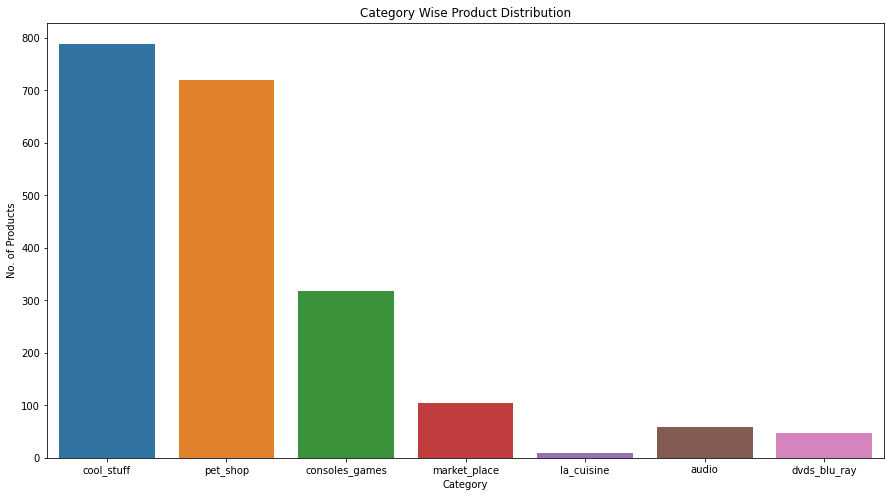

In [39]:
# plotting the category wise distribution of products
plt.figure(figsize=(15,8))
sns.countplot(x='product_category_name_english', data=product)
plt.title('Category Wise Product Distribution')
plt.xlabel('Category')
plt.ylabel('No. of Products')

As we can see, most products are from the cool_stuff and pet_shop categories and the least from the la_cuisine category. 

Next, we plot the distribution of product name lenght. To do this, we use the histplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0.5, 0, 'Product Name Length')

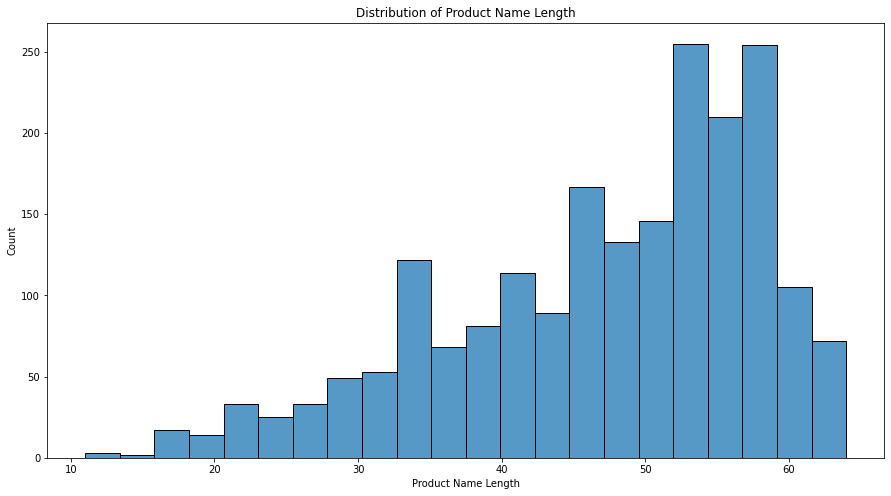

In [40]:
# plotting the distribution of product name length
plt.figure(figsize=(15,8))
sns.histplot(x='product_name_lenght', data=product)
plt.title('Distribution of Product Name Length')
plt.xlabel('Product Name Length')

As we can see, the length of product name is mostly between 45 and 60 characters.

Next, we plot the distribution of product description length. To do this, we use the histplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0.5, 0, 'Product Description Length')

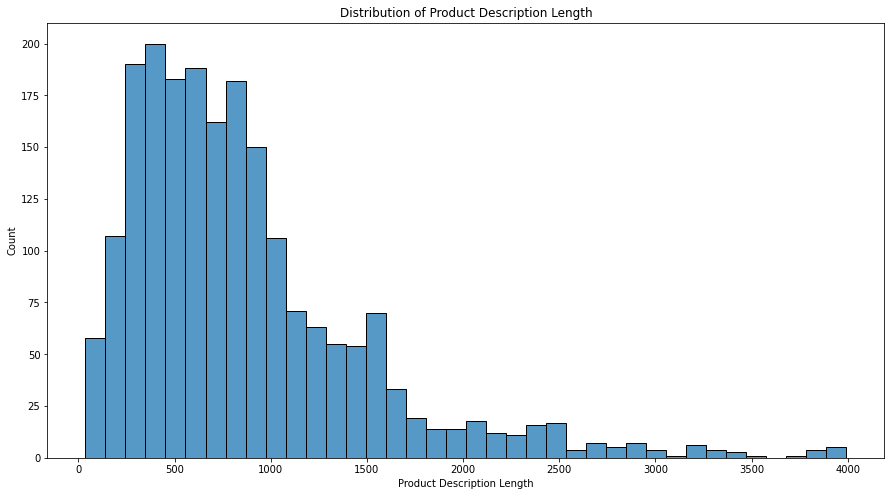

In [41]:
# plotting the distribution of product description length
plt.figure(figsize=(15,8))
sns.histplot(x='product_description_lenght', data=product)
plt.title('Distribution of Product Description Length')
plt.xlabel('Product Description Length')

As we can see, the most of the product description length is between 250 to 1000 characters.

Next, we plot the distribution of product photos quantity. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0.5, 0, 'Product Photos Quantity')

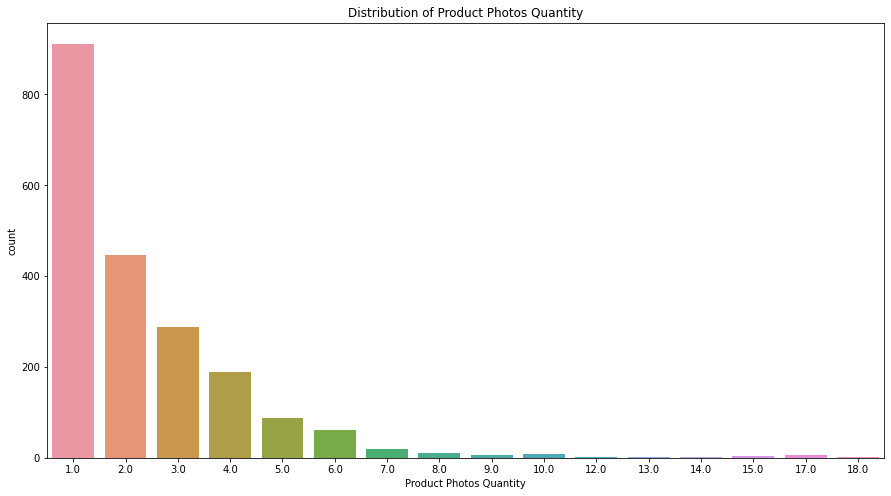

In [42]:
# plotting the distribution of product photos quantity
plt.figure(figsize=(15,8))
sns.countplot(x='product_photos_qty', data=product)
plt.title('Distribution of Product Photos Quantity')
plt.xlabel('Product Photos Quantity')

As we can see, most products have 1 to 3 photos.

#### Seller Table (olist_sellers_dataset)

The Seller Table comprises of the following columns:

- seller_id: seller unique identifier.
- seller_zip_code: first 5 digits of seller zip code.
- seller_city: seller city name.
- seller_state: seller state.

To start off, we view the first few rows of the table using the head() function from the Pandas library.


In [43]:
# viewing the first 5 rows of the table
seller.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


After that, we check for missing values. To do this, we use the isnull() and sum() function from the Pandas library.

In [44]:
# checking for missing values
seller.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

As we can see, there are no missing values.

Next, we visualize the number of sellers per state. To do this, we use the countplot() function from the Seaborn library and functions from the matplotlib library to add aesthetic value.

Text(0, 0.5, 'No. of Sellers')

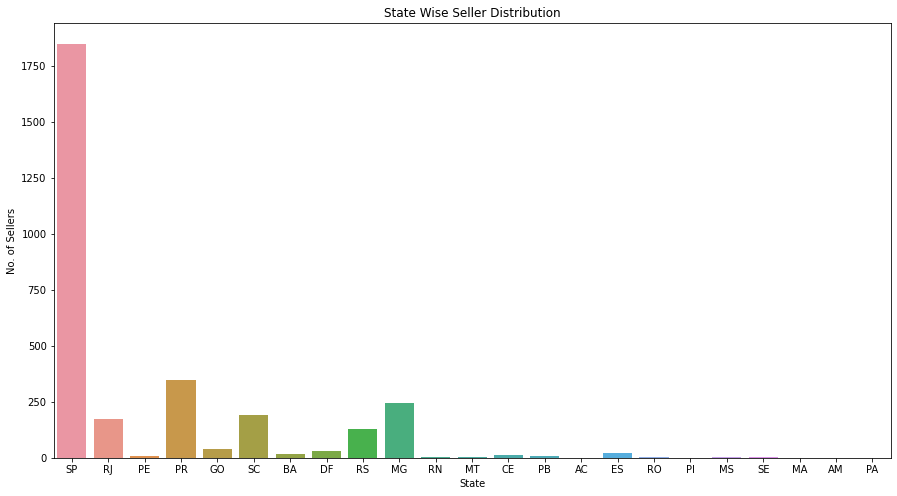

In [45]:
# plotting state wise seller distribution
plt.figure(figsize=(15,8))
sns.countplot(x='seller_state', data=seller)
plt.title('State Wise Seller Distribution')
plt.xlabel('State')
plt.ylabel('No. of Sellers')

As we can see, most number of sellers are from state 'SP', which makes sense since the number customers in that state was also very high.

#### Merging the Datasets

After exploring and performing preprocessing on the datasets individually, we merge the datasets using multiple merge functions and common keys from the database schema. We use the 'inner' join strategy to avoid any missing values.

In [46]:
# merging the datasets
df = pd.merge(order,payment, on='order_id', how='inner')
df = df.merge(review, on='order_id', how='inner')
df = df.merge(customer, on='customer_id', how='inner')
df = df.merge(item, on='order_id', how='inner')
df = df.merge(product, on='product_id', how='inner')
df = df.merge(seller, on='seller_id', how='inner')
df = df.merge(geo, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner')

Next, we view the first few rows of the merged dataset using th head() function from the Pandas library.

In [47]:
# viewing the first few rows of the merged dataset
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,diff_app_pur,diff_car_app,...,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geometry
0,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1073,3,...,pet_shop,31842,belo horizonte,MG,59296,-5.767733,-35.275467,sao goncalo do amarante,RN,POINT (-35.27547 -5.76773)
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1073,3,...,pet_shop,31842,belo horizonte,MG,59296,-5.771622,-35.271325,sao goncalo do amarante,RN,POINT (-35.27133 -5.77162)
2,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1073,3,...,pet_shop,31842,belo horizonte,MG,59296,-5.777424,-35.269238,sao goncalo do amarante,RN,POINT (-35.26924 -5.77742)
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1073,3,...,pet_shop,31842,belo horizonte,MG,59296,-5.771259,-35.271049,sao goncalo do amarante,RN,POINT (-35.27105 -5.77126)
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1073,3,...,pet_shop,31842,belo horizonte,MG,59296,-5.773971,-35.277776,sao goncalo do amarante,RN,POINT (-35.27778 -5.77397)


The merging of datasets may have resulted in duplicate values. To prevent any bias in our prediction, we drop the duplicate values using the drop_duplicates() function from the Pandas library.

In [48]:
# dropping duplicate values
df = df.drop_duplicates()

The dataset is now ready for model building!